<h1>The Correlation Between Time Spent on Social Media and Sleep Among Students</h1>

<h2>1. Business understanding</h2>

   - *Määritellään ratkaistava liiketoimintaongelma (business problem).*
   - *Tavoitteena on selvittää analyysin päämäärä (goal), vaatimukset (requirements), rajoitteet (constraints) ja odotettu lopputulos (expected outcome).*

"How does the time spent on social media affect the amount of sleep?", this is the question we are eager to research and answer.

The effect of social media on sleep, academic performance and mental health has garnered a lot of research and discussion during the past years. Based on this dataset https://www.kaggle.com/datasets/harishyadav0506/impact-of-social-media-on-life that consists of data gathered from high school, undergraduate and postgraduate students on their social media and sleeping habits, academic performance and mental health, we aim to study the correlation between sleep and academic performance, and whether the type of social media has any impact on those two metrics. 

The scope of this study is limited to the dataset in question. It serves to find possible correlations between the subjects, which if found, could indicate further study on the matter.

<h2>2. Data understanding</h2>

   - *Kerätään ja tutkitaan saatavilla olevaa dataa.*
   - *Tässä kartoitetaan datan ominaisuudet, kuten muuttujatyypit ja arvojakaumat, sekä mahdolliset laatuongelmat (quality issues), kuten puuttuvat arvot (missing values), poikkeamat (outliers) ja järjettömät arvot (nonsensical values).*

In [10]:
import numpy as np
import pandas as pd

In [12]:
df_full = pd.read_csv("../datasets/Social_media_impact_on_life.csv")
df_full.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [14]:
df_full.dtypes

Student_ID                      object
Age                              int64
Gender                          object
Academic_Level                  object
Primary_Platform                object
Daily_Usage_Hours              float64
Weekend_Extra_Hours            float64
Device_Type                     object
Sleep_Duration_Hours           float64
Sleep_Quality_Score              int64
Late_Night_Usage                  bool
Social_Comparison_Frequency     object
Perceived_Stress_Score         float64
Mental_Health_Index              int64
Academic_Performance_GPA       float64
Overall_Impact                  object
dtype: object

The dataset has 16 metrics, student id included. The different metrics and their types are as follows:

| Feature Name | Type | Description |
| :- | -: | :-: |
| Student_ID | String | Unique identifier for each participant
| Age | Integer | Participant age (15 to 26 years)
| Gender | String | Self-reported gender category
| Academic_Level | String | High School, Undergraduate, or Postgraduate
| Primary_Platform | String | Most frequently consumed digital platform
| Daily_Usage_Hours | Float | Average daily social media screen time (hours)
| Weekend_Extra_Hours | Float | Supplementary screen time during weekends
| Device_Type | String | Primary device used for access
| Sleep_Duration_Hours | Float | Average nightly sleep duration
| Sleep_Quality_Score | Integer | Self-rated sleep quality (1 to 5 scale)
| Late_Night_Usage | Boolean | Frequent screen time past midnight
| Social_Comparison_Frequency | Categorical (String) | Frequency of social comparison behaviors (Never, Rarely, Sometimes, Frequently, Always)
| Perceived_Stress_Score | Float | PSS psychometric stress indicator (0 to 40)
| Mental_Health_Index | Integer | Composite well-being metric (10 to 98)
| Academic_Performance_GPA | Float | Cumulative GPA (Scale: 1.70 to 4.00)
| Overall_Impact | Categorical (String) | Multi-factor classification outcome (Beneficial, Neutral, Negative)

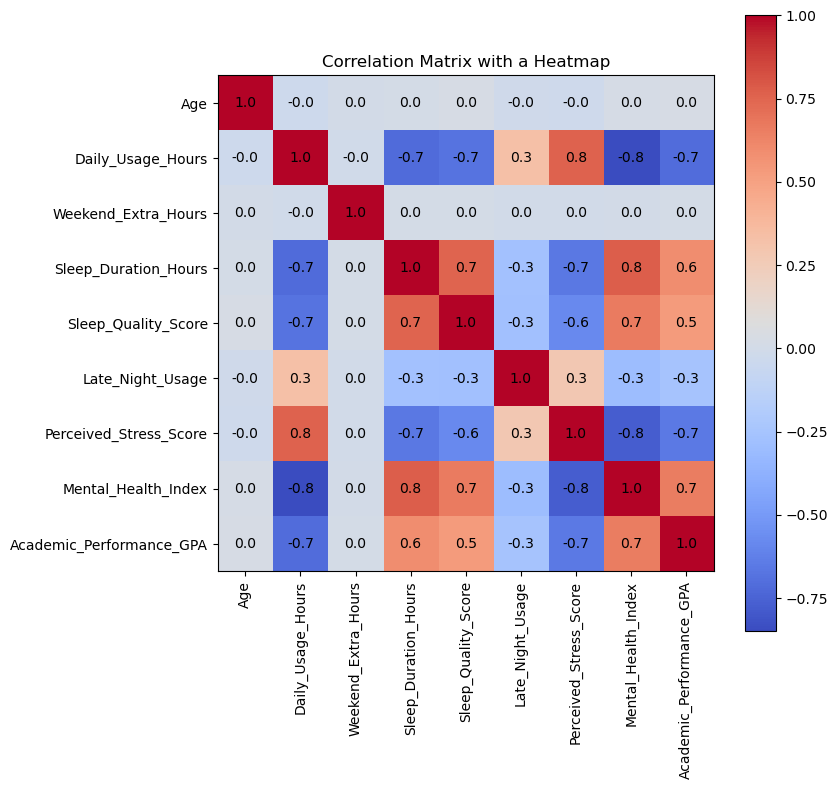

In [325]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.1f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix with a Heatmap')
plt.show()

plt.show()

Based on the correlation heatmap, <b>"Daily_Usage_Hours" (-0.7)</b>, <b>Perceived_Stress_Score, (-0.7)</b>, and <b>Late_Night_Usage (-0.3)</b> have the strongest <b>negative correlation</b> with sleep duration.

Conversely, <b>"mental health index" (+0.8)</b>, <b>"sleep quality" (+0.7)</b>, and <b>"academic performance" (+0.6)</b> display strong <b>positive correlations</b> with sleep duration.

<b>Variables such as age and extra hours on weekends show no notable correlation (~ 0.0) with sleep duration.</b> This indicates that social media usage habits and stress levels play a substantially more critical role in determining student sleep amount than basic demographic factors.

<u><b>Multicollinearity and Feature Selection</b></u><br/>
Multicollinearity was detected between the predictors "Daily_Usage_Hours" and "Perceived_Stress_Score", as <b>they have a strong positive correlation with each other (0.8) and an same negative correlation with sleep duration (-0.7).</b> To eliminate redundancy and stabilize the linear regression model, we drop <b>Perceived_Stress_Score</b> from the feature set.

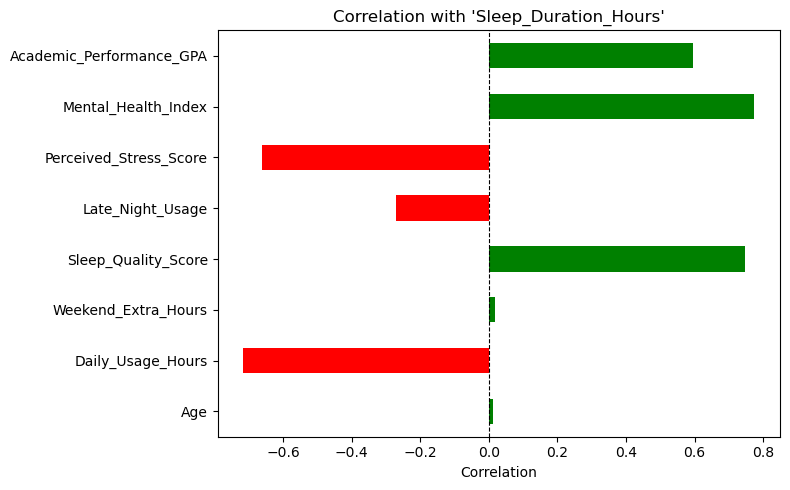

In [332]:
# Visualize correlation only for "Sleep_Duration_hours"
target_corr = (
    correlation_matrix["Sleep_Duration_Hours"]
    .drop("Sleep_Duration_Hours")
)

plt.figure(figsize=(8, 5))
target_corr.plot(
    kind="barh", color=["red" if x < 0 else "green" for x in target_corr]
)

plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlation with 'Sleep_Duration_Hours'")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

<h2>3. Data preparation</h2>

   - *Data siivotaan, muunnetaan ja valitaan olennaiset piirteet (features).*
   - *Kaikki nämä vaiheet tulee dokumentoida niin tarkasti, että ne ovat myöhemmin täysin toistettavissa.*

In [340]:
#remove unnecessary columns
df = df_full.drop(columns=["Student_ID", "Gender", "Overall_Impact", "Academic_Level", "Age", "Perceived_Stress_Score"]).dropna().copy()

#turn boolean values to integers | TRUE = 1, FALSE = 0
df["Late_Night_Usage"] = (df["Late_Night_Usage"].map({False: 0, True: 1, "False": 0, "True": 1}).astype(int))

#One-Hot Encode all reamingn string values
df = pd.get_dummies(df, dtype=int)

df

,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Mental_Health_Index,Academic_Performance_GPA,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Reddit,...,Primary_Platform_X (Twitter),Primary_Platform_YouTube,Device_Type_Laptop/PC,Device_Type_Smartphone,Device_Type_Tablet,Social_Comparison_Frequency_Always,Social_Comparison_Frequency_Frequently,Social_Comparison_Frequency_Never,Social_Comparison_Frequency_Rarely,Social_Comparison_Frequency_Sometimes
0,7.5,1.5,5.9,2,1,73,2.73,0,0,0,...,0,0,0,1,0,1,0,0,0,0
1,4.6,1.3,7.9,3,1,90,3.21,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,10.9,1.7,5.2,1,1,70,3.00,0,0,0,...,0,0,0,1,0,0,1,0,0,0
3,6.0,2.3,7.6,4,1,82,3.42,0,0,0,...,0,1,0,0,1,0,0,0,0,1
4,3.3,2.6,7.6,4,1,84,3.41,0,1,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,5.8,1.2,7.8,3,1,79,2.85,0,0,0,...,0,1,0,1,0,0,0,0,0,1
4496,3.8,3.0,6.6,3,0,83,3.37,0,1,0,...,0,0,0,1,0,0,1,0,0,0
4497,7.7,1.1,6.0,2,1,73,3.16,1,0,0,...,0,0,0,1,0,0,1,0,0,0
4498,4.6,3.3,7.1,3,0,87,3.50,0,1,0,...,0,0,1,0,0,0,0,0,0,1


In [342]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Sleep_Duration_Hours"]).copy()
y = df["Sleep_Duration_Hours"].copy()

#split features and targets to test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [344]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fits the scaler on training data (calculates mean and std) and transforms it
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# transforms test data using training parameters to prevent data leakage
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train_scaled.columns)

X_train_scaled.head()

,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Quality_Score,Late_Night_Usage,Mental_Health_Index,Academic_Performance_GPA,Primary_Platform_Instagram,Primary_Platform_LinkedIn,Primary_Platform_Reddit,Primary_Platform_Snapchat,...,Primary_Platform_X (Twitter),Primary_Platform_YouTube,Device_Type_Laptop/PC,Device_Type_Smartphone,Device_Type_Tablet,Social_Comparison_Frequency_Always,Social_Comparison_Frequency_Frequently,Social_Comparison_Frequency_Never,Social_Comparison_Frequency_Rarely,Social_Comparison_Frequency_Sometimes
0,-0.997905,-0.713220,0.538363,0.832557,1.038223,0.747843,-0.681000,-0.154457,-0.237508,-0.339887,...,-0.213741,2.073685,-0.387274,0.435174,-0.172211,-0.410173,-0.614507,-0.252356,-0.452933,1.357456
1,-0.465909,1.177249,0.538363,0.832557,-0.124163,0.900609,-0.681000,-0.154457,-0.237508,-0.339887,...,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,2.437995,-0.614507,-0.252356,-0.452933,-0.736672
2,0.788083,-1.294903,0.538363,0.832557,-0.434133,-2.129245,-0.681000,-0.154457,-0.237508,-0.339887,...,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,-0.410173,-0.614507,-0.252356,2.207833,-0.736672
3,-0.237910,-2.022006,0.538363,-1.201119,0.185806,-0.474282,-0.681000,-0.154457,-0.237508,-0.339887,...,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,-0.410173,-0.614507,-0.252356,-0.452933,1.357456
4,-0.465909,-0.276958,-0.439041,0.832557,0.495776,-0.805275,1.468428,-0.154457,-0.237508,-0.339887,...,-0.213741,-0.482233,-0.387274,0.435174,-0.172211,-0.410173,1.627320,-0.252356,-0.452933,-0.736672


<h2>4. Modeling</h2>

 - *Valitaan koneoppimismenetelmä, opetetaan malli ja validoidaan se (validation).*
 - *Dokumentointiin on sisällytettävä tarkasti valittu menetelmä, käytetyt parametrit sekä mitattu mallin suorituskyky.*
 - *Millä perusteella tehty valinnat*
 - *Taulukko on hyvä viestimiseen*
 - *Ei tarvitse olla yksityiskohtainen, mutta selitetään miksi on päädytty lopputulokseen.*

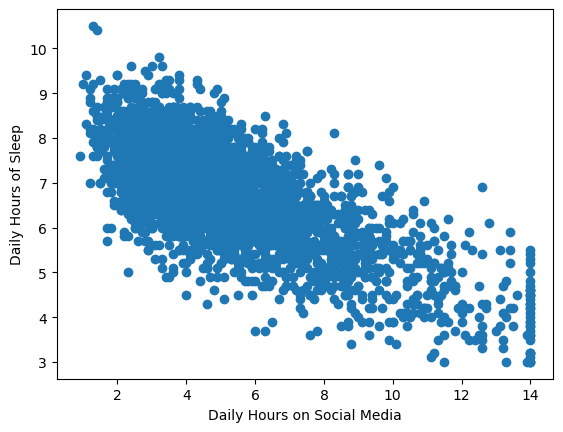

In [286]:
plt.scatter(X_train["Daily_Usage_Hours"], y_train)
plt.xlabel('Daily Hours on Social Media')
plt.ylabel('Daily Hours of Sleep')
plt.show()

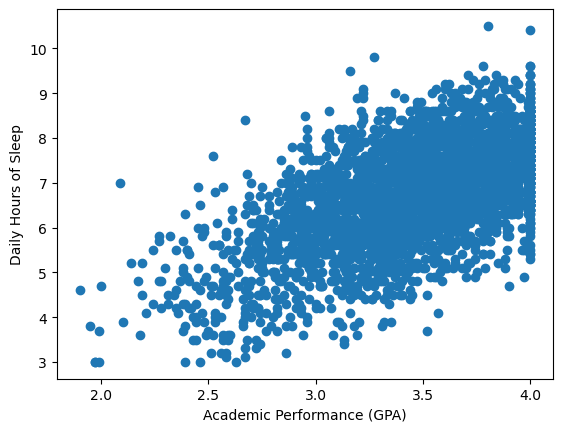

In [249]:
plt.scatter(X_train["Academic_Performance_GPA"], y_train)
plt.xlabel('Academic Performance (GPA)')
plt.ylabel('Daily Hours of Sleep')
plt.show()

<h2>5. Evaluation</h2>

 - *Arvioidaan mallin todellinen onnistuminen.*
 - *Selvitetään, kuinka hyvin malli vastaa sille alun perin asetettuihin liiketoimintavaatimuksiin (business requirements).*<br>
 - *Ei katsota mallin suorituskykyä (tämä tehdään kappaleessa 4), vaan palataan takaisin kappaleeseen 1. ja millä tavalla saavutetut tulokset vertautuu alkuperäisiin tavoitteisiin.*

<h2>6. Deployment</h2>

- *Malli viedään käytäntöön (deployment).*
- *Tähän sisältyy tulosten viestiminen ja suositusten luominen siitä, miten mallia tulisi hyödyntää käytännössä tai mitä jatkotoimenpiteitä tulisi tehdä.**